In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [2]:
RANDOM_SEED = 32
# SELECTION_METRIC must match rfe.ipynb; it maps to the sklearn scoring name used for
# hyperparameter tuning so tuning optimizes the same objective as feature selection.
# BEST_NUM_FEATS (from rfe.ipynb's 1-SE output) and SELECTED_RFE_CSV are set per run.
SELECTION_METRIC = 'brier'
_SCORING = {'brier': 'neg_brier_score', 'roc_auc': 'roc_auc', 'log_loss': 'neg_log_loss'}[SELECTION_METRIC]
BEST_NUM_FEATS = 25
SELECTED_RFE_CSV = 'rfe_features_kfolds_brier.csv'
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    'learning_rate': [.03, .05, .1, .15, .2],
    'max_depth': [2, 3],
    'subsample': [.5, .7, .9],
    'min_child_weight': [10, 20, 50, 100],
    'gamma': [.5, 1, 5, 10, 100],
    'n_estimators': [10, 20,30, 40, 50],
    'early_stopping_rounds': [10, 20, 50],
    'importance_type': ['total_gain'],
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring=_SCORING,
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    f'../../../../../data/predict_games/model_features_in/{SELECTED_RFE_CSV}',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Two-season holdout: train on everything before 2022, use 2022-2023 as the early-stopping
# test slice, and hold out 2024+2025 (the original 3-way split shifted one year forward).
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2022)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2022) & (MODEL_INPUTS_DF['season'] < 2024)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] >= 2024].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.63437	validation_1-auc:0.62105
[1]	validation_0-auc:0.65853	validation_1-auc:0.62439
[2]	validation_0-auc:0.67498	validation_1-auc:0.63180
[3]	validation_0-auc:0.68481	validation_1-auc:0.64437
[4]	validation_0-auc:0.69287	validation_1-auc:0.64711
[5]	validation_0-auc:0.69511	validation_1-auc:0.64997
[6]	validation_0-auc:0.69586	validation_1-auc:0.65019
[7]	validation_0-auc:0.69813	validation_1-auc:0.65275
[8]	validation_0-auc:0.69934	validation_1-auc:0.65822
[0]	validation_0-auc:0.64072	validation_1-auc:0.63390
[9]	validation_0-auc:0.70016	validation_1-auc:0.65898
[1]	validation_0-auc:0.65401	validation_1-auc:0.63509
[10]	validation_0-auc:0.70103	validation_1-auc:0.66035
[2]	validation_0-auc:0.67385	validation_1-auc:0.65077
[11]	validation_0-auc:0.70173	validation_1-auc:0.65980
[12]	validation_0-auc:0.70359	validation_1-auc:0.66069
[13]	validation_0-auc:0.70373	validation_1-auc:0.66169
[3]	validation_0-auc:0.68094	validation_1-auc:0.65788
[14]	validation_0-auc:0.

[31]	validation_0-auc:0.69023	validation_1-auc:0.65564
[28]	validation_0-auc:0.68700	validation_1-auc:0.66139
[36]	validation_0-auc:0.72434	validation_1-auc:0.65800
[14]	validation_0-auc:0.71221	validation_1-auc:0.66037
[27]	validation_0-auc:0.68751	validation_1-auc:0.65988
[28]	validation_0-auc:0.68811	validation_1-auc:0.65935
[25]	validation_0-auc:0.70771	validation_1-auc:0.65602
[32]	validation_0-auc:0.69099	validation_1-auc:0.65571
[33]	validation_0-auc:0.69305	validation_1-auc:0.65597
[9]	validation_0-auc:0.70592	validation_1-auc:0.66521
[29]	validation_0-auc:0.68687	validation_1-auc:0.66053
[28]	validation_0-auc:0.68835	validation_1-auc:0.66037
[15]	validation_0-auc:0.71314	validation_1-auc:0.65941
[29]	validation_0-auc:0.68794	validation_1-auc:0.65915
[26]	validation_0-auc:0.70790	validation_1-auc:0.65600
[33]	validation_0-auc:0.69176	validation_1-auc:0.65597
[30]	validation_0-auc:0.68738	validation_1-auc:0.65910
[37]	validation_0-auc:0.72434	validation_1-auc:0.65800
[21]	valida

[7]	validation_0-auc:0.68348	validation_1-auc:0.65505
[3]	validation_0-auc:0.65845	validation_1-auc:0.64000
[46]	validation_0-auc:0.70283	validation_1-auc:0.66214
[8]	validation_0-auc:0.68810	validation_1-auc:0.66652
[36]	validation_0-auc:0.69776	validation_1-auc:0.65606
[42]	validation_0-auc:0.70113	validation_1-auc:0.66904
[35]	validation_0-auc:0.69857	validation_1-auc:0.66514
[28]	validation_0-auc:0.69705	validation_1-auc:0.65638
[8]	validation_0-auc:0.68955	validation_1-auc:0.66166
[1]	validation_0-auc:0.63342	validation_1-auc:0.60637
[0]	validation_0-auc:0.61746	validation_1-auc:0.60649
[8]	validation_0-auc:0.68520	validation_1-auc:0.65472
[47]	validation_0-auc:0.70311	validation_1-auc:0.66265
[9]	validation_0-auc:0.68785	validation_1-auc:0.66455
[37]	validation_0-auc:0.69809	validation_1-auc:0.65646
[36]	validation_0-auc:0.69917	validation_1-auc:0.66624
[43]	validation_0-auc:0.70133	validation_1-auc:0.66849
[9]	validation_0-auc:0.68965	validation_1-auc:0.66277
[29]	validation_0-a

[8]	validation_0-auc:0.65395	validation_1-auc:0.63821
[7]	validation_0-auc:0.64625	validation_1-auc:0.62980
[4]	validation_0-auc:0.66138	validation_1-auc:0.64084
[7]	validation_0-auc:0.67381	validation_1-auc:0.64107
[8]	validation_0-auc:0.66996	validation_1-auc:0.64616
[9]	validation_0-auc:0.65395	validation_1-auc:0.63821
[3]	validation_0-auc:0.62321	validation_1-auc:0.60507
[8]	validation_0-auc:0.64625	validation_1-auc:0.62980
[8]	validation_0-auc:0.67483	validation_1-auc:0.64489
[10]	validation_0-auc:0.65395	validation_1-auc:0.63821
[9]	validation_0-auc:0.67001	validation_1-auc:0.64409
[9]	validation_0-auc:0.65367	validation_1-auc:0.63793
[5]	validation_0-auc:0.66296	validation_1-auc:0.64669
[11]	validation_0-auc:0.65395	validation_1-auc:0.63821
[0]	validation_0-auc:0.63642	validation_1-auc:0.62095
[9]	validation_0-auc:0.67575	validation_1-auc:0.64791
[10]	validation_0-auc:0.65367	validation_1-auc:0.63793
[4]	validation_0-auc:0.63771	validation_1-auc:0.61884
[12]	validation_0-auc:0.6

[16]	validation_0-auc:0.65797	validation_1-auc:0.64194
[14]	validation_0-auc:0.65789	validation_1-auc:0.64068
[19]	validation_0-auc:0.70965	validation_1-auc:0.65048
[3]	validation_0-auc:0.66727	validation_1-auc:0.65261
[12]	validation_0-auc:0.65367	validation_1-auc:0.63793
[12]	validation_0-auc:0.65628	validation_1-auc:0.64350
[17]	validation_0-auc:0.65797	validation_1-auc:0.64194
[0]	validation_0-auc:0.62751	validation_1-auc:0.61512
[9]	validation_0-auc:0.65039	validation_1-auc:0.63916
[0]	validation_0-auc:0.62811	validation_1-auc:0.61552
[13]	validation_0-auc:0.65367	validation_1-auc:0.63793
[4]	validation_0-auc:0.67380	validation_1-auc:0.65687
[13]	validation_0-auc:0.65628	validation_1-auc:0.64350
[18]	validation_0-auc:0.65797	validation_1-auc:0.64194
[1]	validation_0-auc:0.63779	validation_1-auc:0.62648
[14]	validation_0-auc:0.65367	validation_1-auc:0.63793
[1]	validation_0-auc:0.64810	validation_1-auc:0.64000
[14]	validation_0-auc:0.65628	validation_1-auc:0.64350
[5]	validation_0-

...

[46]	validation_0-auc:0.71226	validation_1-auc:0.66009


[47]	validation_0-auc:0.71226	validation_1-auc:0.66009


[48]	validation_0-auc:0.71226	validation_1-auc:0.66009


[49]	validation_0-auc:0.71226	validation_1-auc:0.66009




Best parameters found:  {'subsample': 0.9, 'n_estimators': 50, 'min_child_weight': 50, 'max_depth': 2, 'learning_rate': 0.2, 'importance_type': 'total_gain', 'gamma': 10, 'eval_metric': 'auc', 'early_stopping_rounds': 20}


Best score found:  -0.22468453984696204


Best Selected Features:  ['def_target_run_right_end_yards_per_attempt_garbage_trailing_cumulative_average_rank', 'def_target_yac_over_expected_competitive_cumulative_average_rank', 'is_home_target', 'off_opp_success_rate_competitive_cumulative_average_rank', 'target_def_cumulative_avg_points_allowed_rank', 'def_opp_fumble_lost_rate_competitive_cumulative_average_rank', 'def_target_pass_deep_middle_explosive_rate_competitive_cumulative_average_rank', 'off_target_pass_short_left_yards_per_attempt_garbage_trailing_cumulative_average_rank', 'def_opp_pass_short_left_yards_per_attempt_garbage_trailing_cumulative_average_rank', 'off_target_success_rate_competitive_cumulative_average_rank', 'def_opp_run_right_end_yards_per_attempt

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.15143976, 0.16787305, 0.14822717, 0.14067326, 0.14952383,
        0.05496144, 0.08065743, 0.07057686, 0.12245893, 0.11600442,
        0.0506566 , 0.05668983, 0.13392906, 0.1125504 , 0.12475686,
        0.08348846, 0.08110104, 0.08420477, 0.07244182, 0.05304599,
        0.04940286, 0.08219395, 0.12168069, 0.1054719 , 0.11341071,
        0.15918069, 0.07743077, 0.07141438, 0.11687303, 0.10597024,
        0.10678277, 0.16533198, 0.08256998, 0.14173837, 0.05631909,
        0.053722  , 0.08490448, 0.10289798, 0.05106359, 0.08073268,
        0.13662963, 0.16862473, 0.05955997, 0.08278766, 0.11080632,
        0.05208678, 0.05176983, 0.08729982, 0.09307904, 0.16022635,
        0.10797896, 0.05442877, 0.16545439, 0.04804983, 0.12817926,
        0.08499002, 0.17514038, 0.05474138, 0.13280115, 0.07361188,
        0.09900894, 0.10772047, 0.05477023, 0.05458384, 0.0785192 ,
        0.10819459, 0.07236733, 0.08472157, 0.10953097, 0.15382338,
        0.10893335, 0.08122315,

<Axes: >

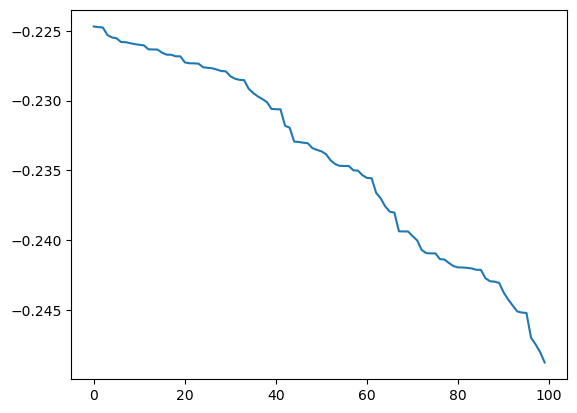

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,...,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.129038,0.010257,0.001934,0.000844,0.9,50,50,2,0.2,total_gain,...,20,"{'subsample': 0.9, 'n_estimators': 50, 'min_ch...",-0.226128,-0.225437,-0.228220,-0.223045,-0.220592,-0.224685,0.002630,1
1,0.148227,0.017705,0.002878,0.001264,0.9,40,50,3,0.2,total_gain,...,50,"{'subsample': 0.9, 'n_estimators': 40, 'min_ch...",-0.223948,-0.223150,-0.228693,-0.226739,-0.221110,-0.224728,0.002681,2
2,0.118020,0.016633,0.001895,0.000360,0.7,40,100,3,0.2,total_gain,...,20,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",-0.225475,-0.227197,-0.226339,-0.223371,-0.221418,-0.224760,0.002100,3
3,0.151440,0.013916,0.004121,0.003971,0.5,40,20,3,0.15,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 40, 'min_ch...",-0.227014,-0.224944,-0.225955,-0.228612,-0.219968,-0.225298,0.002929,4
4,0.149524,0.012011,0.001804,0.000200,0.7,50,100,2,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",-0.226116,-0.224393,-0.226936,-0.228304,-0.221603,-0.225470,0.002311,5


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.6452205882352942

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Single overall hold-out AUROC, computed exactly like bart.ipynb, reported alongside
# Brier/log-loss so every run is comparable on all axes regardless of selection metric.
overall_holdout_auroc = roc_auc_score(holdout_df['target_win'], holdout_df['preds'])
print(f'2024+2025 hold-out ROC-AUC (overall): {overall_holdout_auroc:.4f}  '
      f'[{BEST_NUM_FEATS} features, {SELECTED_RFE_CSV}, selected on {SELECTION_METRIC}]')

2024+2025 hold-out ROC-AUC (overall): 0.7005  [25 features, rfe_features_kfolds_brier.csv, selected on brier]


In [13]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2024_01_ARI_BUF,1,ARI,BUF,0,0.215662
1,2024_01_ARI_BUF,1,BUF,ARI,1,0.814587
2,2024_01_BAL_KC,1,KC,BAL,1,0.616621
3,2024_01_BAL_KC,1,BAL,KC,0,0.429841
4,2024_01_CAR_NO,1,CAR,NO,0,0.263239
...,...,...,...,...,...,...
1083,2025_18_SEA_SF,18,SF,SEA,0,0.558005
1084,2025_18_TEN_JAX,18,JAX,TEN,1,0.781042
1085,2025_18_TEN_JAX,18,TEN,JAX,0,0.207523
1086,2025_18_WAS_PHI,18,PHI,WAS,0,0.764245


week
1     0.889648
2     0.634766
3     0.553711
4     0.679688
5     0.484694
6     0.745541
7     0.830000
8     0.738407
9     0.741974
10    0.656888
11    0.745541
12    0.762689
13    0.750977
14    0.787380
15    0.781250
16    0.612305
17    0.669922
18    0.609375
dtype: float64

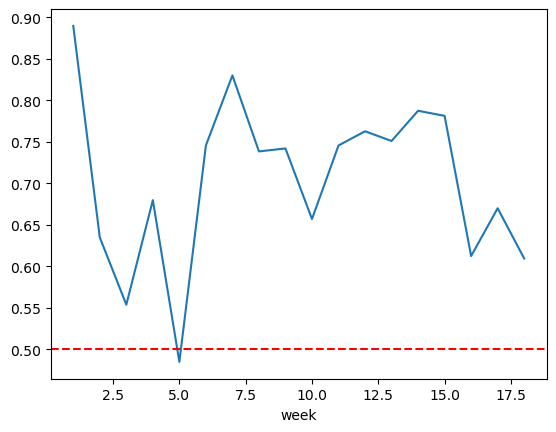

In [14]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [15]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.820513
2     0.583333
3     0.640625
4     0.811765
5     0.405128
6     0.715789
7     0.664596
8     0.611111
9     0.583333
10    0.566845
11    0.700000
12    0.614286
13    0.688312
14    0.703947
15    0.536458
16    0.734375
17    0.595833
18    0.481781
dtype: float64

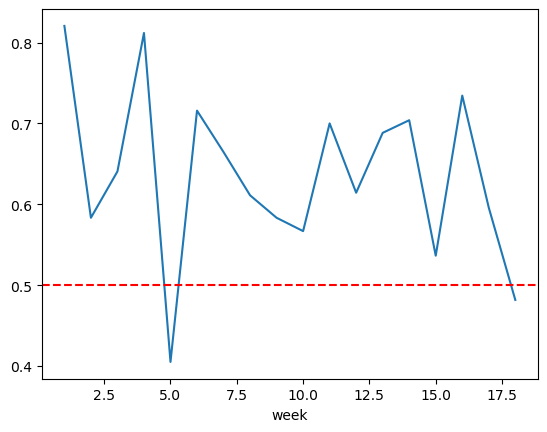

In [16]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

## How good are the model's *confident* predictions?

AUROC only measures **ranking** (can the model sort winners above losers?). It says
nothing about whether a 0.80 prediction is actually right ~80% of the time. The cells
below answer "when the model has a strong prediction, how well does it predict?" using:

1. **Brier score & log loss** — residual-based metrics that penalize overconfidence.
2. **Confidence-bucketed accuracy** — the direct answer: how often the favored team wins,
   grouped by how sure the model was.
3. **Reliability diagram** — visual calibration check (predicted prob vs observed win rate).

Note: `holdout_df` has two rows per `game_id` (one per team). Brier/log loss are computed
on all rows consistently; the bucketed-accuracy table uses the one-row-per-game `higher_preds`
frame so each game is counted once.

In [17]:
# Residual-based metrics. Unlike AUROC, these penalize confident-and-wrong predictions.
from sklearn.metrics import brier_score_loss, log_loss

brier = brier_score_loss(holdout_df['target_win'], holdout_df['preds'])
ll = log_loss(holdout_df['target_win'], holdout_df['preds'])
print(f"Brier score: {brier:.4f}  (lower is better; 0.25 = coin flip)")
print(f"Log loss:    {ll:.4f}  (lower is better; punishes confident-and-wrong hardest)")

Brier score: 0.2200  (lower is better; 0.25 = coin flip)
Log loss:    0.6297  (lower is better; punishes confident-and-wrong hardest)


In [18]:
# Confidence-bucketed accuracy: the direct answer to "when the model is confident, is it right?"
# On higher_preds, `preds` is the model's confidence in its pick (0.5-1.0) and
# target_win == 1 means the favored team actually won.
higher_preds['confidence'] = higher_preds['preds']
higher_preds['bucket'] = pd.cut(
    higher_preds['confidence'], bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

confidence_summary = higher_preds.groupby('bucket', observed=True).agg(
    n_games=('target_win', 'size'),
    pick_accuracy=('target_win', 'mean'),   # how often the favored team won
    avg_confidence=('confidence', 'mean'),  # what the model claimed
)
# Positive gap = overconfident (claimed more than it delivered)
confidence_summary['calibration_gap'] = (
    confidence_summary['avg_confidence'] - confidence_summary['pick_accuracy']
)
confidence_summary

,n_games,pick_accuracy,avg_confidence,calibration_gap
bucket,,,,
"(0.5, 0.6]",225,0.546667,0.553938,0.007272
"(0.6, 0.7]",173,0.710983,0.646507,-0.064475
"(0.7, 0.8]",106,0.726415,0.745275,0.018860
"(0.8, 0.9]",13,1.000000,0.830530,-0.169470


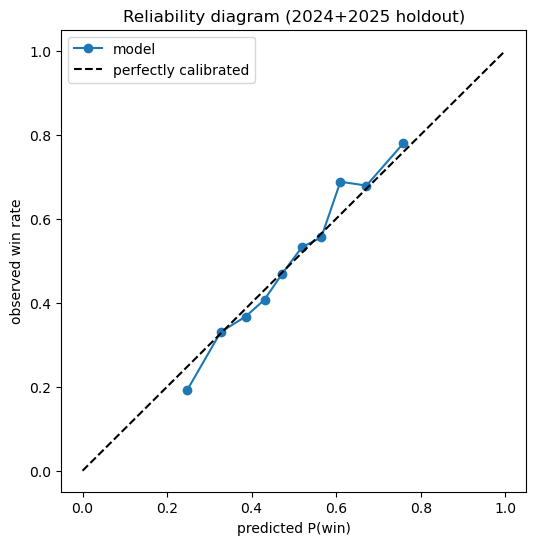

In [19]:
# Reliability diagram: are the probabilities trustworthy?
# Points on the diagonal = perfectly calibrated. Below the diagonal on the right
# side = the model is overconfident when bullish.
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    holdout_df['target_win'], holdout_df['preds'], n_bins=10, strategy='quantile'
)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='model')
plt.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
plt.xlabel('predicted P(win)')
plt.ylabel('observed win rate')
plt.title('Reliability diagram (2024+2025 holdout)')
plt.legend()
plt.show()

## Does a wider home-vs-away gap mean better predictions?

Each game has two predictions: `P(home wins)` from the home-perspective row and
`P(away wins)` from the away-perspective row. The **gap** between them is a stronger
confidence signal than `max(pred)` alone — it uses *both* perspectives. A wide gap
means the two views agree strongly on a winner; a narrow gap means the model is torn.

Hypothesis: when the gap is wide, accuracy should be higher. We pivot the two rows onto
one row per game (via `is_home_target`), define the model's pick as whichever side has
the higher probability, and bucket accuracy by gap width (quintiles, so every bin is
populated).

In [20]:
# Pivot the two perspectives of each game onto one row (is_home_target: 1 = home, 0 = away)
game_view = holdout_df.pivot_table(
    index='game_id', columns='is_home_target', values=['preds', 'target_win'], aggfunc='first'
).dropna()

games = pd.DataFrame({
    'home_pred': game_view[('preds', 1)],
    'away_pred': game_view[('preds', 0)],
    'home_won':  game_view[('target_win', 1)].astype(int),
})
games['gap']           = games['home_pred'] - games['away_pred']   # >0 leans home, <0 leans away
games['abs_gap']       = games['gap'].abs()                        # strength of the lean
games['pred_home_win'] = games['home_pred'] > games['away_pred']
games['correct']       = games['pred_home_win'] == (games['home_won'] == 1)

# Bucket by gap width (quintiles) and measure accuracy in each
games['gap_quintile'] = pd.qcut(games['abs_gap'], 5)
gap_summary = games.groupby('gap_quintile', observed=True).agg(
    n_games=('correct', 'size'),
    mean_abs_gap=('abs_gap', 'mean'),
    accuracy=('correct', 'mean'),
)
print(f"Overall correlation(abs_gap, correct): {games['abs_gap'].corr(games['correct'].astype(int)):.3f}")
gap_summary

Overall correlation(abs_gap, correct): 0.210


,n_games,mean_abs_gap,accuracy
gap_quintile,,,
"(0.00412, 0.0955]",109,0.049512,0.504587
"(0.0955, 0.173]",109,0.133479,0.559633
"(0.173, 0.274]",108,0.220625,0.685185
"(0.274, 0.414]",109,0.342720,0.697248
"(0.414, 0.715]",109,0.505875,0.779817


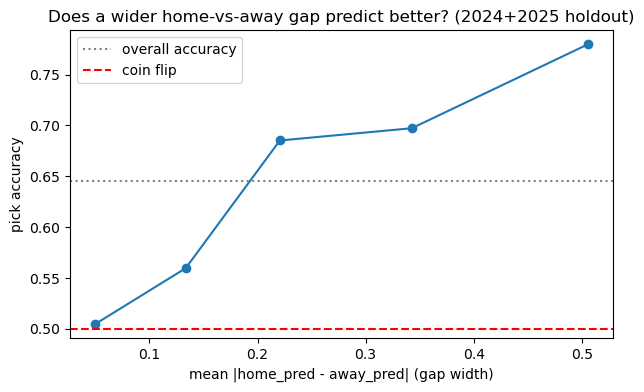

In [21]:
# Visualize the hypothesis: accuracy should rise as the home-vs-away gap widens
plt.figure(figsize=(7, 4))
plt.plot(gap_summary['mean_abs_gap'], gap_summary['accuracy'], marker='o')
plt.axhline(y=games['correct'].mean(), color='gray', linestyle=':', label='overall accuracy')
plt.axhline(y=0.5, color='r', linestyle='--', label='coin flip')
plt.xlabel('mean |home_pred - away_pred| (gap width)')
plt.ylabel('pick accuracy')
plt.title('Does a wider home-vs-away gap predict better? (2024+2025 holdout)')
plt.legend()
plt.show()